Male: 89 model-confirmed Class 3 patients


100%|████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  4.74it/s]


  Male 10/89 (0.4 min)


100%|████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:03<00:00,  3.88s/it]


  Male 20/89 (2.6 min)


...

  Female 50/66 (5.8 min)


100%|████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:03<00:00,  3.93s/it]


  Female 60/66 (7.0 min)


100%|████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  3.60it/s]


Female: done in 7.3 min -> _cohort_female.csv

merged cohort rows: 620 | patients: 155

=== Condition summary (both sexes pooled) ===
               n  feasibility  mean_valid_cands  any_viol  diversity  mean_changed
cond_h                                                                            
C0_pure      155        1.000             3.935      0.91     15.241        15.260
C1_posthoc   155        0.000             0.000       NaN        NaN           NaN
C2_pre_rule  155        0.987             3.413      0.00      5.229        10.607

=== Condition summary by sex ===
                     n  feasibility  mean_valid_cands  any_viol  diversity  mean_changed
gender cond_h                                                                           
Female C0_pure      66        1.000             3.970     0.894     14.133        14.760
       C1_posthoc   66        0.000             0.000       NaN        NaN           NaN
       C2_pre_rule  66        1.000             3.455     0.0

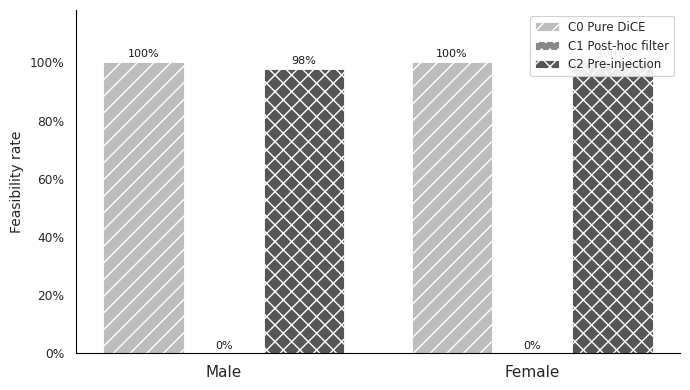

posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


  saved -> ..\results\figures\fig_condition_diversity.png
  saved -> ..\results\figures\fig_condition_diversity.pdf


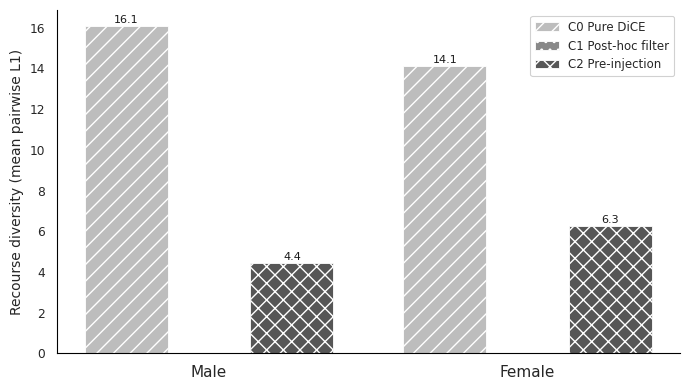

posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


  saved -> ..\results\figures\fig_condition_sparsity.png
  saved -> ..\results\figures\fig_condition_sparsity.pdf


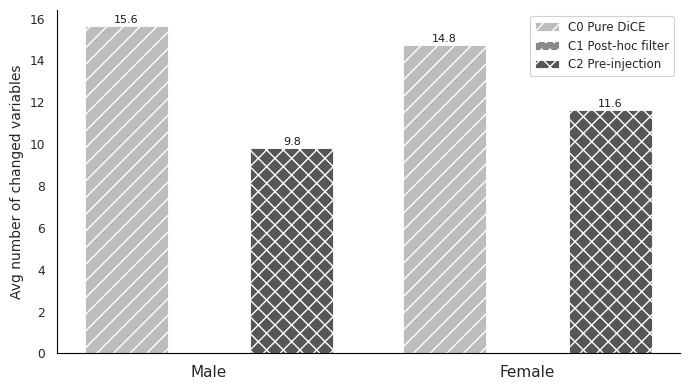


saved -> table_condition_comparison.tex
saved -> table_delegation.tex

DONE.


In [1]:
# 04_condition_comparison.ipynb
# The redesigned core experiment: a four-condition comparison over ALL
# model-confirmed Class 3 patients in the held-out validation set. This notebook
# is SELF-CONTAINED -- it runs the cohort loop itself (caching the per-gender
# results to CSV) and then builds the tables and grayscale figures.
#
# Conditions
#   C0 pure       : unconstrained DiCE (Class 0 target, no fallback)
#   C1 posthoc    : unconstrained DiCE + post-hoc removal of safety-violating
#                   candidates  (feasibility collapses when all are dropped)
#   C2 pre_rule   : rule-based guardrail injected before search + stepwise
#                   fallback, at two delegation levels (aggressive/conservative)
#
# Claim (b): the value of the framework is NOT the 0% violation rate (true by
# construction for any pre-injection / post-hoc scheme) but that PRE-INJECTION
# preserves feasibility and recourse diversity where POST-HOC FILTERING destroys
# them. Violation rate is reported only as a sanity check.
#
# Runtime: the cohort loop is the slow part (genetic DiCE + fallback). It caches
# to ../results/tables/_cohort_{male,female}.csv; set FORCE_RERUN = True to
# recompute. On a laptop CPU expect ~10 min (male, n~87) and ~15 min
# (female, n~69).
#
# Inputs  (../data/): df_final.pkl, agent_config.pkl, model_*.pkl, val_*.pkl
# Modules (../notebooks/): guardrail_core.py, experiment_core.py
# Outputs (../results/tables/): _cohort_male.csv, _cohort_female.csv,
#                     experiment_cohort.csv, table_condition_comparison.tex,
#                     table_delegation.tex
# Figures (../results/figures/): fig_condition_feasibility,
#                     fig_condition_diversity, fig_condition_sparsity

import os
import time
import warnings
import joblib
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

import guardrail_core as gc
import experiment_core as ec

import os
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
FIG_DIR = os.path.join("..", "results", "figures")
TAB_DIR = os.path.join("..", "results", "tables")
os.makedirs(FIG_DIR, exist_ok=True); os.makedirs(TAB_DIR, exist_ok=True)
sns.set_theme(style="white", context="paper"); sns.set_palette("Greys")
mpl.rcParams.update({"savefig.dpi": 600, "font.family": "DejaVu Sans",
    "font.size": 10, "axes.edgecolor": "#000000", "axes.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False, "axes.grid": False})
GREY_LEVELS = ["#BDBDBD", "#888888", "#565656", "#1A1A1A"]
HATCHES     = ["", "//", "..", "xx", "\\"]
GREY_PAIR   = ["#9E9E9E", "#3A3A3A"]
def save_fig(fig, name):
    for ext in ("png", "pdf"):
        p = os.path.join(FIG_DIR, f"{name}.{ext}")
        fig.savefig(p, dpi=600, bbox_inches="tight", format=ext); print("  saved ->", p)


DATA = os.path.join("..", "data")
df_final = joblib.load(os.path.join(DATA, "df_final.pkl"))
ac = joblib.load(os.path.join(DATA, "agent_config.pkl"))
X = ac["X_features"]; T = ac["target_col"]; VARY = ac["vary_features"]

FORCE_RERUN = False   # set True to recompute even if cached CSVs exist

KEEP = ["feasible", "achieved_class", "fallback_depth", "n_valid_cands",
        "n_changed_vars", "diversity", "anthro_viol", "energy_viol",
        "conflict_viol", "any_viol"]


# ---------------------------------------------------------------------------
# Cohort loop for one gender (C0, C1, and C2 at two delegation levels)
# ---------------------------------------------------------------------------
def run_gender(gender_code, gender_name, model_file, val_file):
    cache = os.path.join(TAB_DIR, f"_cohort_{gender_name.lower()}.csv")
    if os.path.exists(cache) and not FORCE_RERUN:
        print(f"{gender_name}: using cached {os.path.basename(cache)}")
        return pd.read_csv(cache)

    model = joblib.load(os.path.join(DATA, model_file))
    val = joblib.load(os.path.join(DATA, val_file))
    df_stable = df_final[df_final["Sex"] == gender_code].copy().astype(float)
    idx = val["X_val"][(val["y_val"] == 3) &
                       (model.predict(val["X_val"]) == 3)].index.tolist()
    exp = ec.make_dice(model, df_stable, X, T)
    print(f"{gender_name}: {len(idx)} model-confirmed Class 3 patients")

    rows = []
    t0 = time.time()
    for k, pid in enumerate(idx):
        q = val["X_val"].loc[[pid]][X]
        cur = {f: float(q.iloc[0][f]) for f in X}
        r0 = ec.eval_C0_pure(exp, q, df_stable, X, VARY)
        rows.append({"pid": pid, "gender": gender_name, "deleg": "-",
                     "cond": "C0_pure", **{kk: r0[kk] for kk in KEEP}})
        r1 = ec.eval_C1_posthoc(exp, q, df_stable, X, VARY, cur)
        rows.append({"pid": pid, "gender": gender_name, "deleg": "-",
                     "cond": "C1_posthoc", **{kk: r1[kk] for kk in KEEP}})
        for deleg in ["aggressive", "conservative"]:
            g_rule = gc.build_rule_guardrails(cur, X, deleg)
            r2 = ec.eval_pre_injection(exp, q, df_stable, X, VARY, g_rule)
            rows.append({"pid": pid, "gender": gender_name, "deleg": deleg,
                         "cond": "C2_pre_rule", **{kk: r2[kk] for kk in KEEP}})
        if (k + 1) % 10 == 0:
            print(f"  {gender_name} {k+1}/{len(idx)} ({(time.time()-t0)/60:.1f} min)")
    df_g = pd.DataFrame(rows)
    df_g.to_csv(cache, index=False)
    print(f"{gender_name}: done in {(time.time()-t0)/60:.1f} min -> {os.path.basename(cache)}")
    return df_g


df_male = run_gender(1.0, "Male", "model_male.pkl", "val_male.pkl")
df_female = run_gender(2.0, "Female", "model_female.pkl", "val_female.pkl")

# ---------------------------------------------------------------------------
# Merge (+ optional LLM/C3 run if present)
# ---------------------------------------------------------------------------
df = pd.concat([df_male, df_female], ignore_index=True)
llm_path = os.path.join(TAB_DIR, "_cohort_llm.csv")
if os.path.exists(llm_path):
    df = pd.concat([df, pd.read_csv(llm_path)], ignore_index=True)
df.to_csv(os.path.join(TAB_DIR, "experiment_cohort.csv"), index=False)
print("\nmerged cohort rows:", len(df), "| patients:", df["pid"].nunique())

# ---------------------------------------------------------------------------
# Condition-level summary
# ---------------------------------------------------------------------------
def cond_view(d):
    d = d.copy()
    d["cond_h"] = d["cond"]
    d = d[~((d["cond"] == "C2_pre_rule") & (d["deleg"] == "conservative"))]
    return d

dh = cond_view(df)

def summarise(d, by):
    feas = d[d["feasible"]]
    g = d.groupby(by)
    return pd.DataFrame({
        "n": g.size(),
        "feasibility": g["feasible"].mean(),
        "mean_valid_cands": g["n_valid_cands"].mean(),
        "any_viol": feas.groupby(by)["any_viol"].mean(),
        "diversity": feas.groupby(by)["diversity"].mean(),
        "mean_changed": feas.groupby(by)["n_changed_vars"].mean(),
    })

COND_ORDER = ["C0_pure", "C1_posthoc", "C2_pre_rule"]
COND_LABEL = {"C0_pure": "C0 Pure DiCE", "C1_posthoc": "C1 Post-hoc filter",
              "C2_pre_rule": "C2 Pre-injection"}

print("\n=== Condition summary (both sexes pooled) ===")
print(summarise(dh, "cond_h").reindex(COND_ORDER).round(3).to_string())

bysex = summarise(dh, ["gender", "cond_h"])
print("\n=== Condition summary by sex ===")
print(bysex.round(3).to_string())

c2 = df[df["cond"] == "C2_pre_rule"]
deleg = summarise(c2, ["gender", "deleg"])
print("\n=== Delegation ablation (C2 pre-injection) ===")
print(deleg.round(3).to_string())

# ---------------------------------------------------------------------------
# Grayscale figures
# ---------------------------------------------------------------------------
def bar_by_condition(metric, ylabel, fname, as_pct=True, ymax=None):
    genders = ["Male", "Female"]
    fig, ax = plt.subplots(figsize=(7, 4))
    x = np.arange(len(genders)); w = 0.26
    for i, cond in enumerate(COND_ORDER):
        vals = []
        for g in genders:
            vals.append(bysex.loc[(g, cond)][metric] if (g, cond) in bysex.index else 0.0)
        bars = ax.bar(x + (i - 1) * w, vals, width=w, color=GREY_LEVELS[i],
                      hatch=HATCHES[i + 1], edgecolor="white", linewidth=0.6,
                      label=COND_LABEL[cond])
        for bar, v in zip(bars, vals):
            txt = f"{v:.0%}" if as_pct else f"{v:.1f}"
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + (0.01 if as_pct else 0.05),
                    txt, ha="center", va="bottom", fontsize=8, color="#1A1A1A")
    ax.set_xticks(x); ax.set_xticklabels(genders, fontsize=11)
    ax.set_ylabel(ylabel, fontsize=10)
    if as_pct:
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
        ax.set_ylim(0, ymax or 1.15)
    elif ymax:
        ax.set_ylim(0, ymax)
    ax.legend(fontsize=8.5, loc="upper right", framealpha=0.9)
    plt.tight_layout(); save_fig(fig, fname); plt.show()

bar_by_condition("feasibility", "Feasibility rate", "fig_condition_feasibility",
                 as_pct=True, ymax=1.18)
bar_by_condition("diversity", "Recourse diversity (mean pairwise L1)",
                 "fig_condition_diversity", as_pct=False)
bar_by_condition("mean_changed", "Avg number of changed variables",
                 "fig_condition_sparsity", as_pct=False)

# ---------------------------------------------------------------------------
# LaTeX tables
# ---------------------------------------------------------------------------
def pct(x): return "--" if pd.isna(x) else f"{x:.1%}"
def num(x): return "--" if pd.isna(x) else f"{x:.2f}"

lines = [r"\begin{table}[ht]", r"\centering",
         r"\caption{Four-condition comparison on all model-confirmed Class~3 "
         r"patients in the held-out validation set. Pre-injection (C2) preserves "
         r"feasibility and recourse diversity, whereas post-hoc filtering (C1) "
         r"eliminates all candidates once safety filtering is applied. The 0\% "
         r"violation rate of C1 and C2 is by construction and is reported only as "
         r"a consistency check; the operative contrast is feasibility.}",
         r"\label{tab:condition_comparison}", r"\setlength{\tabcolsep}{5pt}",
         r"\begin{tabular}{llccccc}", r"\toprule",
         r"Gender & Condition & Feasibility & Valid cands & Diversity "
         r"& Avg vars & Any viol. \\", r"\midrule"]
for g in ["Male", "Female"]:
    for i, cond in enumerate(COND_ORDER):
        if (g, cond) not in bysex.index:
            continue
        r = bysex.loc[(g, cond)]
        cell = r"\multirow{3}{*}{" + g + r"}" if i == 0 else ""
        lines.append(
            f"  {cell} & {COND_LABEL[cond]} & {pct(r['feasibility'])} "
            f"& {num(r['mean_valid_cands'])} & {num(r['diversity'])} "
            f"& {num(r['mean_changed'])} & {pct(r['any_viol'])} \\\\")
    lines.append(r"  \midrule")
lines += [r"\bottomrule", r"\end{tabular}", r"\end{table}"]
with open(os.path.join(TAB_DIR, "table_condition_comparison.tex"), "w") as f:
    f.write("\n".join(lines))
print("\nsaved -> table_condition_comparison.tex")

lines = [r"\begin{table}[ht]", r"\centering",
         r"\caption{Delegation ablation for the pre-injection condition (C2): "
         r"aggressive vs.\ conservative Layer-2 delegation. Robust feasibility "
         r"under both settings indicates that enforcing only the absolute safety "
         r"floors (aggressive) does not degrade recourse availability.}",
         r"\label{tab:delegation}", r"\begin{tabular}{llcccc}", r"\toprule",
         r"Gender & Delegation & Feasibility & Valid cands & Diversity & Avg vars \\",
         r"\midrule"]
for g in ["Male", "Female"]:
    for i, dl in enumerate(["aggressive", "conservative"]):
        if (g, dl) not in deleg.index:
            continue
        r = deleg.loc[(g, dl)]
        cell = r"\multirow{2}{*}{" + g + r"}" if i == 0 else ""
        lines.append(
            f"  {cell} & {dl.capitalize()} & {pct(r['feasibility'])} "
            f"& {num(r['mean_valid_cands'])} & {num(r['diversity'])} "
            f"& {num(r['mean_changed'])} \\\\")
    lines.append(r"  \midrule")
lines += [r"\bottomrule", r"\end{tabular}", r"\end{table}"]
with open(os.path.join(TAB_DIR, "table_delegation.tex"), "w") as f:
    f.write("\n".join(lines))
print("saved -> table_delegation.tex")
print("\nDONE.")
